In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

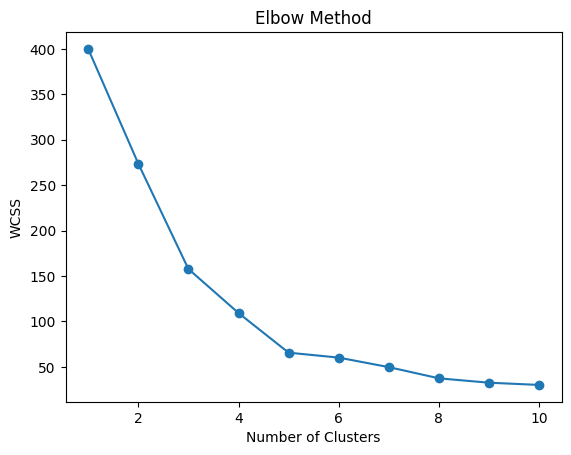

In [6]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=5, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

df['Cluster'] = y_kmeans

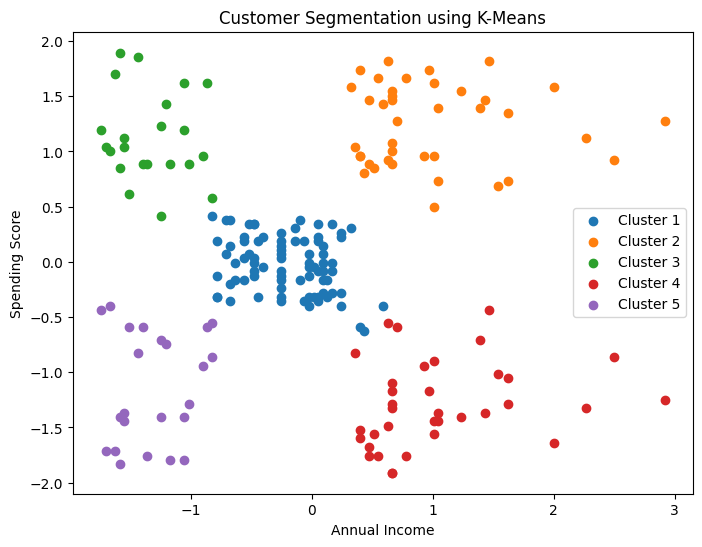

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(X_scaled[y_kmeans==0,0], X_scaled[y_kmeans==0,1], label="Cluster 1")
plt.scatter(X_scaled[y_kmeans==1,0], X_scaled[y_kmeans==1,1], label="Cluster 2")
plt.scatter(X_scaled[y_kmeans==2,0], X_scaled[y_kmeans==2,1], label="Cluster 3")
plt.scatter(X_scaled[y_kmeans==3,0], X_scaled[y_kmeans==3,1], label="Cluster 4")
plt.scatter(X_scaled[y_kmeans==4,0], X_scaled[y_kmeans==4,1], label="Cluster 5")

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()

plt.show()

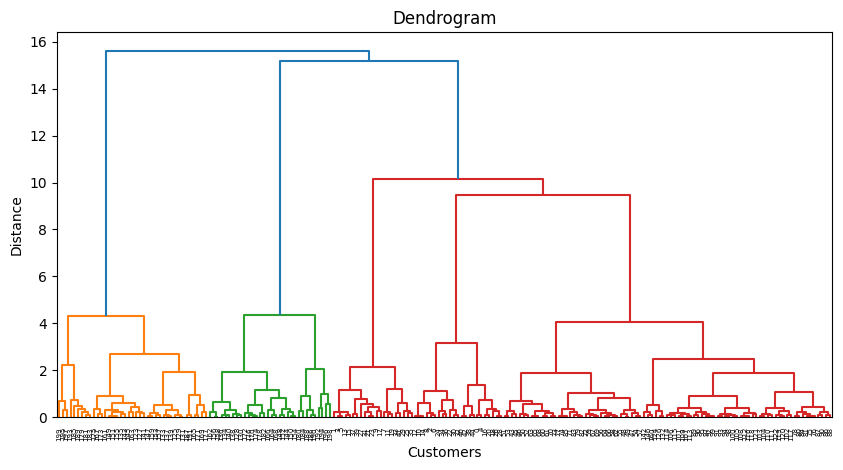

In [10]:
plt.figure(figsize=(10,5))

dendrogram(linkage(X_scaled, method='ward'))

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")

plt.show()

In [11]:
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')

y_hc = hc.fit_predict(X_scaled)

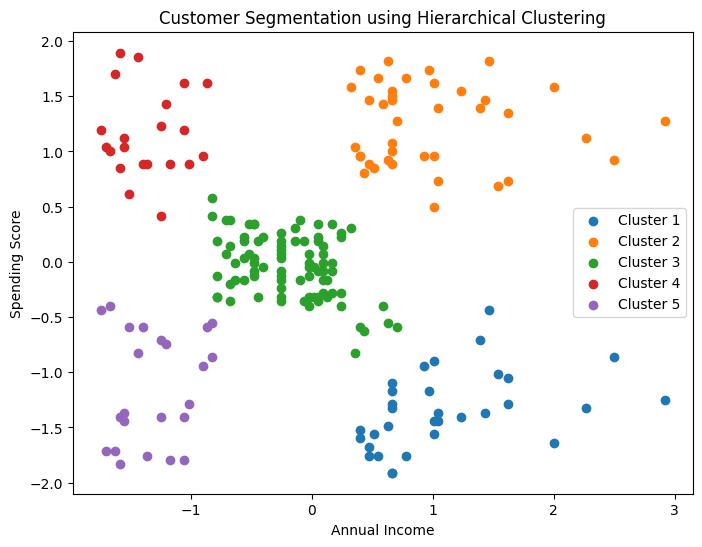

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(X_scaled[y_hc==0,0], X_scaled[y_hc==0,1], label="Cluster 1")
plt.scatter(X_scaled[y_hc==1,0], X_scaled[y_hc==1,1], label="Cluster 2")
plt.scatter(X_scaled[y_hc==2,0], X_scaled[y_hc==2,1], label="Cluster 3")
plt.scatter(X_scaled[y_hc==3,0], X_scaled[y_hc==3,1], label="Cluster 4")
plt.scatter(X_scaled[y_hc==4,0], X_scaled[y_hc==4,1], label="Cluster 5")

plt.title("Customer Segmentation using Hierarchical Clustering")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.legend()

plt.show()